# Статистический анализ доступа к интернету среди разных типов домохозяйств в Европе
## Описательный, выводной и визуальный анализ данных

Цели данного задания:

- Исследование и описание структуры данных.

- Формулирование и проверка статистической гипотезы.

- Интерпретация результатов в прикладном контексте.

Используемый набор данных: isoc_ci_in_h$defaultview_linear_2_0.csv (Eurostat, показатель доступа домохозяйств к интернету).

### Раздел импорта
Эта ячейка импортирует все необходимые библиотеки для анализа данных, статистики и построения графиков.  
Эти инструменты используются для описательного анализа (`pandas`, `numpy`), визуализации (`matplotlib`, `seaborn`) и статистических проверок (`scipy`, `statsmodels`).  
Также для графической визуализации устанавливается белый фон и размер графика 10 на 6.

In [422]:
import itertools
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## I. Введение

### Цель анализа
Цель данного задания — применить основные статистические методы: описательные, выводные и визуальные — для исследования уровня доступа домохозяйств к интернету в зависимости от типа домохозяйства, страны и года.

### Статистические задачи
1. Описать распределение числовой переменной `OBS_VALUE` (процент домохозяйств с доступом к интернету).
2. Проанализировать частоты для категориальных переменных (`Type of household`, `Geopolitical entity (reporting)`).
3. Оценить одно среднее значение и одну долю с 95% доверительными интервалами.
4. Проверить гипотезу о среднем значении генеральной совокупности (t-тест).
5. Проверить независимость между двумя категориальными переменными (хи-квадрат тест).
6. Сравнить средние значения между более чем двумя группами (ANOVA), включая проверку предположений.

### Описание набора данных
- Источник: Eurostat (`ISOC_CI_IN_H`, экспорт CSV) [Eurostat](https://ec.europa.eu/eurostat/databrowser/view/isoc_ci_in_h/default/table?lang=en&category=isoc.isoc_i.isoc_ici).
- Единица измерения: процент домохозяйств.
- Переменные, используемые в анализе:
  - числовые: `OBS_VALUE`, `TIME_PERIOD`;
  - категориальные: `Type of household`, `Geopolitical entity (reporting)`.

### Загрузка данных
Эта ячейка загружает CSV-файл, оставляет только ключевые переменные, используемые в задании, переименовывает столбцы, удаляет пропущенные/некорректные значения и создаёт подвыборку для самого последнего года.  
Также подсчитывается количество наблюдений, стран, типов домохозяйств и лет, доступных после очистки данных.

In [ ]:
# Load and select relevant variables
file_path = "isoc_ci_in_h__custom_20543865_linear_2_0.csv"
raw = pd.read_csv(file_path)

cols = {
    "Geopolitical entity (reporting)": "country",
    "Type of household": "household_type",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "internet_access_pct",
}

df = raw[list(cols.keys())].rename(columns=cols)
df = df.dropna(subset=["internet_access_pct", "household_type", "country", "year"]).copy()

# Keep observations within the valid percentage range
df = df[(df["internet_access_pct"] >= 0) & (df["internet_access_pct"] <= 100)]

latest_year = int(df["year"].max())
df_latest = df[df["year"] == latest_year].copy()

print(f"Number of observations (after cleaning): {len(df)}")
print(f"Number of countries: {df['country'].nunique()}")
print(f"Number of household types: {df['household_type'].nunique()}")
print(f"Year range: {int(df['year'].min())} - {int(df['year'].max())}")
print(f"Observations in the most recent year ({latest_year}): {len(df_latest)}")

df.head()


Number of observations (after cleaning): 1439
Number of countries: 43
Number of household types: 4
Year range: 2016 - 2025
Observations in the most recent year (2025): 140


,country,household_type,year,internet_access_pct
0,Albania,Single person,2018,56.73
1,Albania,Single person,2020,58.56
2,Albania,Single person,2021,70.76
3,Albania,Single person,2022,89.59
4,Albania,Single person,2023,83.19


## II. Описательный анализ и визуализация данных (Темы 1–3)

# Годовая динамика


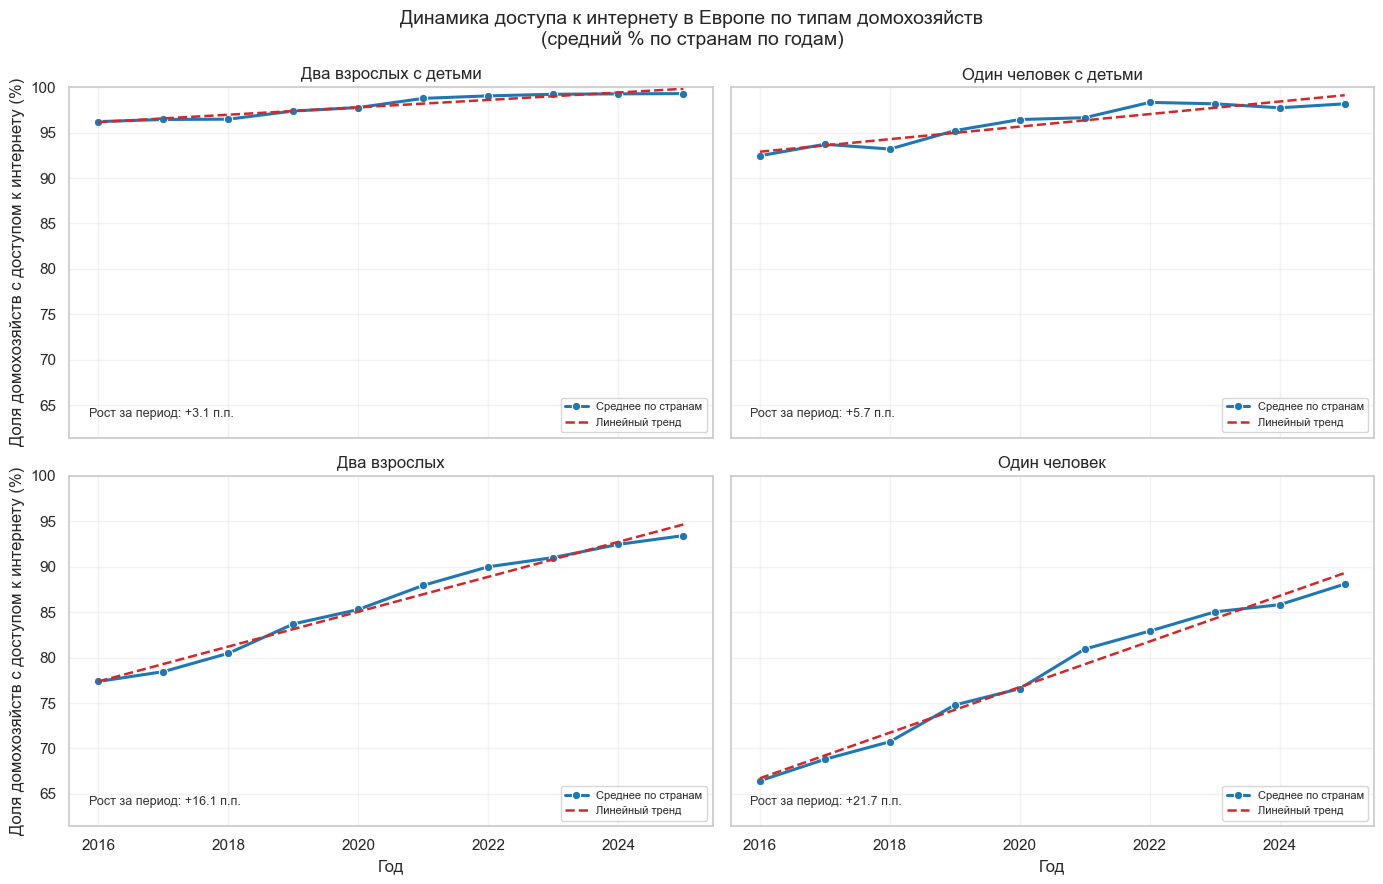

In [438]:
# Годовая динамика: 4 мини-графика (small multiples) по типам домохозяйств
type_labels_ru = {
    "Single person": "Один человек",
    "Single person with dependent children": "Один человек с детьми",
    "Two adults": "Два взрослых",
    "Two adults with dependent children": "Два взрослых с детьми",
}

dynamic_by_year = (
    df.groupby(["year", "household_type"], as_index=False)["internet_access_pct"]
    .mean()
)

order_types = (
    dynamic_by_year.groupby("household_type")["internet_access_pct"]
    .mean()
    .sort_values(ascending=False)
    .index
)

y_min = max(0, dynamic_by_year["internet_access_pct"].min() - 5)
y_max = min(100, dynamic_by_year["internet_access_pct"].max() + 2)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, household_type in zip(axes, order_types):
    tmp = dynamic_by_year[dynamic_by_year["household_type"] == household_type].sort_values("year")

    sns.lineplot(
        data=tmp,
        x="year",
        y="internet_access_pct",
        marker="o",
        linewidth=2.2,
        color="#1f77b4",
        ax=ax,
        label="Среднее по странам",
    )

    if len(tmp) >= 2:
        z = np.polyfit(tmp["year"], tmp["internet_access_pct"], 1)
        trend = np.poly1d(z)(tmp["year"])
        ax.plot(
            tmp["year"],
            trend,
            linestyle="--",
            linewidth=1.8,
            color="#d62728",
            label="Линейный тренд",
        )

        delta = tmp.iloc[-1]["internet_access_pct"] - tmp.iloc[0]["internet_access_pct"]
        ax.text(
            0.03,
            0.06,
            f"Рост за период: {delta:+.1f} п.п.",
            transform=ax.transAxes,
            fontsize=9,
            color="#333333",
        )

    ax.set_title(type_labels_ru.get(household_type, household_type))
    ax.set_xlabel("Год")
    ax.set_ylabel("Доля домохозяйств с доступом к интернету (%)")
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right", fontsize=8, frameon=True)

plt.suptitle(
    "Динамика доступа к интернету в Европе по типам домохозяйств\n(средний % по странам по годам)",
    fontsize=14,
)
plt.tight_layout()
plt.show()


### Основные описательные статистики
Эта ячейка вычисляет основные описательные статистики для процента доступа к интернету: количество наблюдений, среднее значение, медиану, стандартное отклонение, минимум и максимум.  
Расчёты выполняются как для всего набора данных, так и для самого последнего года.  
В результате получается сводка показателей центральной тенденции и разброса, показывающая общий уровень и вариативность доступа к интернету.

In [439]:
# Descriptive statistics for the numeric variable
numeric_stats_all = df["internet_access_pct"].agg(["count", "mean", "median", "std", "min", "max"])
numeric_stats_latest = df_latest["internet_access_pct"].agg(["count", "mean", "median", "std", "min", "max"])

print("Descriptive statistics - all observations:")
display(numeric_stats_all.to_frame(name="value"))

print(f"Descriptive statistics - year {latest_year}:")
display(numeric_stats_latest.to_frame(name="value"))


Descriptive statistics - all observations:


,value
count,1439.000000
mean,89.177630
median,94.920000
std,13.130033
min,21.130000
max,100.000000


Descriptive statistics - year 2025:


,value
count,140.000000
mean,94.644571
median,97.375000
std,6.626777
min,65.790000
max,100.000000


### Частоты и доли
Эта ячейка подсчитывает частоты и доли для **категориальных** переменных.  
Она показывает, как часто встречается каждый тип домохозяйства.  
В результате получается профиль распределения категориальных данных.

In [440]:
# Frequencies and proportions for categorical variables
freq_household = df["household_type"].value_counts().to_frame("frequency")
freq_household["proportion"] = freq_household["frequency"] / len(df)

freq_country = df["country"].value_counts().to_frame("frequency")
freq_country["proportion"] = freq_country["frequency"] / len(df)

print("Frequencies and proportions - household types:")
display(freq_household)

# print("Top 10 countries by observation frequency:")
# display(freq_country.head(10))


Frequencies and proportions - household types:


,frequency,proportion
household_type,,
Two adults with dependent children,373,0.259208
Two adults,372,0.258513
Single person,371,0.257818
Single person with dependent children,323,0.224461


### Визуализация за 2025 год

В этом блоке используются данные только за `2025` год. Показываем распределение по типам домохозяйств, среднее, медиану и порог `95%`.

Чтобы график был читаемым, используются две шкалы:
- общая: от `60` до `100`;
- зум около порога: от `90` до `100`.


??? ???????: 2025
????? ? ???????: 140
????? ???? ????? ? ???????? >=95%: 64.3%


,household_type_ru,n,mean,median,min,max,share_ge_95
3,???+????,36,99.29,99.34,95.23,100.00,100.00
1,????+????,32,98.16,99.12,89.91,100.00,90.62
2,???,36,93.42,94.76,80.83,99.83,47.22
0,????,36,88.09,89.74,65.79,99.37,22.22


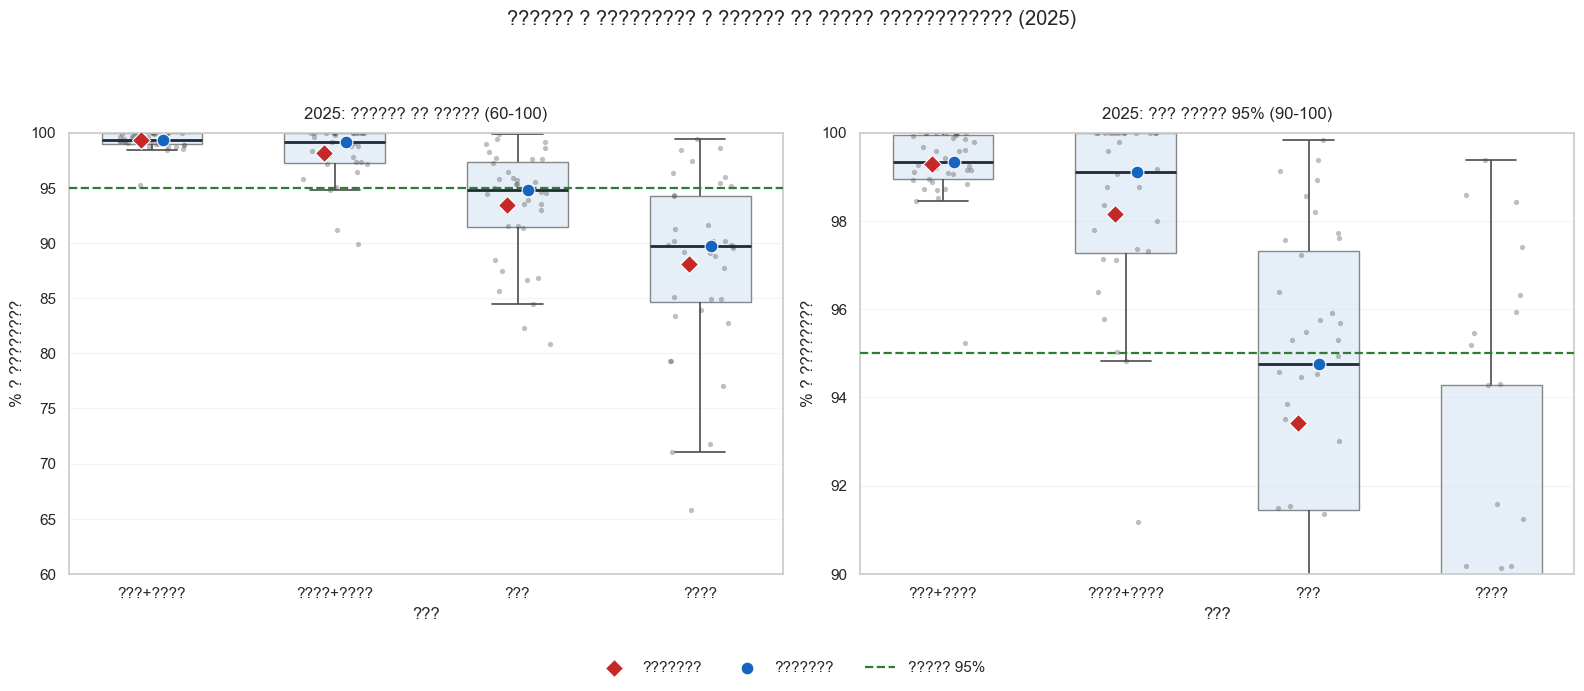

In [441]:
# ?????? 2025 ???
target_year = 2025

type_labels_short = {
    "Single person": "????",
    "Single person with dependent children": "????+????",
    "Two adults": "???",
    "Two adults with dependent children": "???+????",
}

df_2025 = df[df["year"] == target_year].copy()
if df_2025.empty:
    raise ValueError("??? ?????? ?? 2025 ??? ??? ????????? ???????.")

df_2025["household_type_ru"] = df_2025["household_type"].map(type_labels_short).fillna(df_2025["household_type"])

summary_2025 = (
    df_2025.groupby("household_type", as_index=False)
    .agg(
        n=("internet_access_pct", "size"),
        mean=("internet_access_pct", "mean"),
        median=("internet_access_pct", "median"),
        min=("internet_access_pct", "min"),
        max=("internet_access_pct", "max"),
        share_ge_95=("internet_access_pct", lambda s: (s >= 95).mean() * 100),
    )
    .sort_values("mean", ascending=False)
)
summary_2025["household_type_ru"] = summary_2025["household_type"].map(type_labels_short).fillna(summary_2025["household_type"])

order_by_mean_ru = summary_2025["household_type_ru"].tolist()
overall_share_ge_95 = (df_2025["internet_access_pct"] >= 95).mean() * 100

print(f"??? ???????: {target_year}")
print(f"????? ? ???????: {len(df_2025)}")
print(f"????? ???? ????? ? ???????? >=95%: {overall_share_ge_95:.1f}%")
display(summary_2025[["household_type_ru", "n", "mean", "median", "min", "max", "share_ge_95"]].round(2))

# ??? ??????: ????? ????? ? ??? ????? ?????? 95%
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
panels = [
    (axes[0], 60, "2025: ?????? ?? ????? (60-100)"),
    (axes[1], 90, "2025: ??? ????? 95% (90-100)"),
]

x_pos = np.arange(len(order_by_mean_ru))
x_pos_mean = x_pos - 0.06
x_pos_median = x_pos + 0.06
means = summary_2025.set_index("household_type_ru").loc[order_by_mean_ru, "mean"].to_numpy()
medians = summary_2025.set_index("household_type_ru").loc[order_by_mean_ru, "median"].to_numpy()

for ax, y_min, panel_title in panels:
    sns.boxplot(
        data=df_2025,
        x="household_type_ru",
        y="internet_access_pct",
        order=order_by_mean_ru,
        showfliers=False,
        width=0.55,
        boxprops={"facecolor": "#d9e6f5", "alpha": 0.65, "zorder": 1},
        whiskerprops={"linewidth": 1.2, "zorder": 2},
        capprops={"linewidth": 1.2, "zorder": 2},
        medianprops={"color": "#1f2937", "linewidth": 2.0, "zorder": 3},
        ax=ax,
    )
    sns.stripplot(
        data=df_2025,
        x="household_type_ru",
        y="internet_access_pct",
        order=order_by_mean_ru,
        jitter=0.18,
        alpha=0.35,
        size=3.8,
        color="#4a4a4a",
        zorder=2,
        ax=ax,
    )

    ax.scatter(x_pos_mean, means, color="#c62828", marker="D", s=85, edgecolors="white", linewidths=0.8, zorder=6, label="???????")
    ax.scatter(x_pos_median, medians, color="#1565c0", marker="o", s=85, edgecolors="white", linewidths=0.8, zorder=6, label="???????")
    ax.axhline(95, color="#2e7d32", linestyle="--", linewidth=1.6, zorder=4, label="????? 95%")

    ax.set_title(panel_title, pad=10)
    ax.set_xlabel("???")
    ax.set_ylabel("% ? ????????")
    ax.set_ylim(y_min, 100)
    ax.grid(axis="y", alpha=0.2, zorder=0)
    ax.tick_params(axis="x", rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=3, frameon=False)
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.suptitle("?????? ? ????????? ? ?????? ?? ????? ???????????? (2025)", y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()


### Доступ к интернету по типам домохозяйств
Эта ячейка сравнивает распределения по типам домохозяйств за самый последний год с помощью boxplot-графиков.  

Она анализирует медианы, разброс и потенциальные выбросы для каждой группы.  

Сравнение на уровне групп показывает, какие типы домохозяйств, как правило, имеют более высокий или более низкий уровень доступа к интернету.

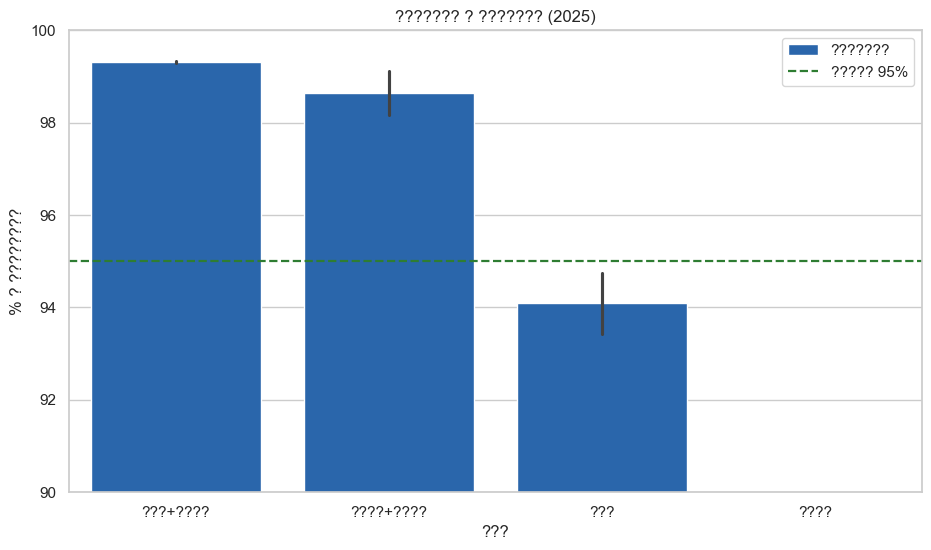

,household_type_ru,mean,median
3,???+????,99.29,99.34
1,????+????,98.16,99.12
2,???,93.42,94.76
0,????,88.09,89.74


In [442]:
# ??????? ? ??????? ?? ????? ???????????? (2025)
mean_median_long = summary_2025[["household_type_ru", "mean", "median"]].melt(
    id_vars="household_type_ru",
    var_name="metric",
    value_name="value",
)
mean_median_long["metric"] = mean_median_long["metric"].map(
    {"mean": "???????", "median": "???????"}
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=mean_median_long,
    x="household_type_ru",
    y="value",
    hue="metric",
    order=order_by_mean_ru,
    palette={"???????": "#c62828", "???????": "#1565c0"},
)
plt.axhline(95, color="#2e7d32", linestyle="--", linewidth=1.6, label="????? 95%")
plt.title("??????? ? ??????? (2025)")
plt.xlabel("???")
plt.ylabel("% ? ????????")
plt.xticks(rotation=0)
plt.ylim(90, 100)
plt.legend()
plt.show()

summary_2025[["household_type_ru", "mean", "median"]].round(2)


### Столбчатая диаграмма
Эта ячейка вычисляет и строит диаграмму среднего уровня доступа к интернету для каждого типа домохозяйств за самый последний год.  

Она позволяет напрямую сравнить средние значения по группам.  

Результат: наглядный рейтинг типов домохозяйств по среднему уровню доступа к интернету.

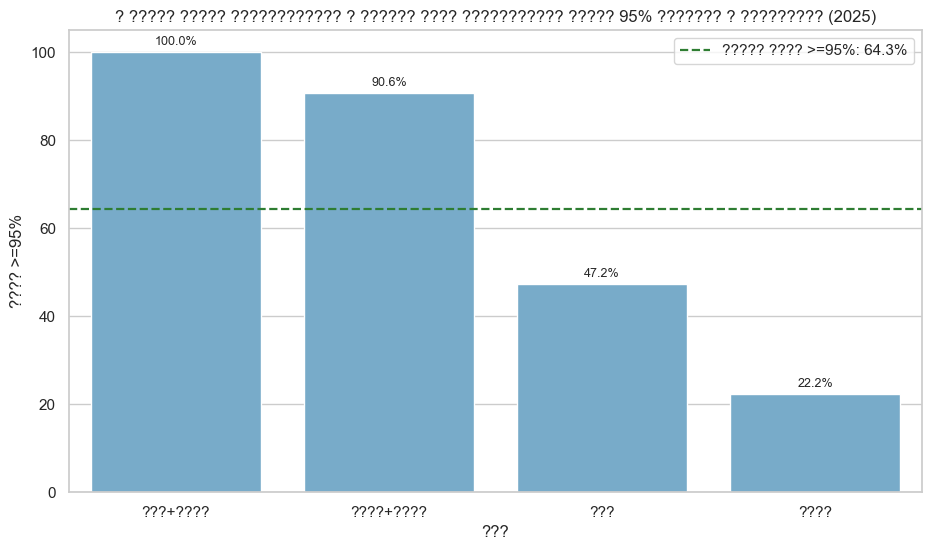

,household_type_ru,share_ge_95
3,???+????,100.00
1,????+????,90.62
2,???,47.22
0,????,22.22


In [443]:
# ???? ????? ? ??????? ??????? >=95% ?? ????? ???????????? (2025)
share_95 = summary_2025[["household_type_ru", "share_ge_95"]].copy()

plt.figure(figsize=(11, 6))
sns.barplot(
    data=share_95,
    x="household_type_ru",
    y="share_ge_95",
    order=order_by_mean_ru,
    color="#6baed6",
)

for i, val in enumerate(share_95.set_index("household_type_ru").loc[order_by_mean_ru, "share_ge_95"]):
    plt.text(i, val + 1, f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

plt.axhline(
    overall_share_ge_95,
    color="#2e7d32",
    linestyle="--",
    linewidth=1.6,
    label=f"????? ???? >=95%: {overall_share_ge_95:.1f}%",
)
plt.title("? ????? ????? ???????????? ? ?????? ???? ??????????? ????? 95% ??????? ? ????????? (2025)")
plt.xlabel("???")
plt.ylabel("???? >=95%")
plt.xticks(rotation=0)
plt.ylim(0, 105)
plt.legend()
plt.show()

share_95.round(2)


### ??????? ????? ?? ?????? ?????? ??????? (2025, ? fallback)
? ???????? ?????? ??? ????????? ????????? `Total`, ??????? ????? ?????????? ?????? ?????????????? ?? 4 ????? ????????????.

??? ???????:
- ??? ?????? ???? `?????? ? ???` ????? ???????? ?? `2025`; ???? ??? ??? ? ????????? ?????????? ??? (fallback);
- ????? ??????? ????? ?????????? ?????? ??? ?????????? ??????? ?? ????? ????????????.

?? ???????:
- ???? ?????? = ????? % ??????? ? ?????????;
- ??????? ?????? ?????? = ??????.

??? ????????? ???????? ?????? ????? ? ???????? ?????? ??-?? ????????? ? 2025 ????.


C:\Users\art\AppData\Local\Temp\ipykernel_7636\2441711050.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


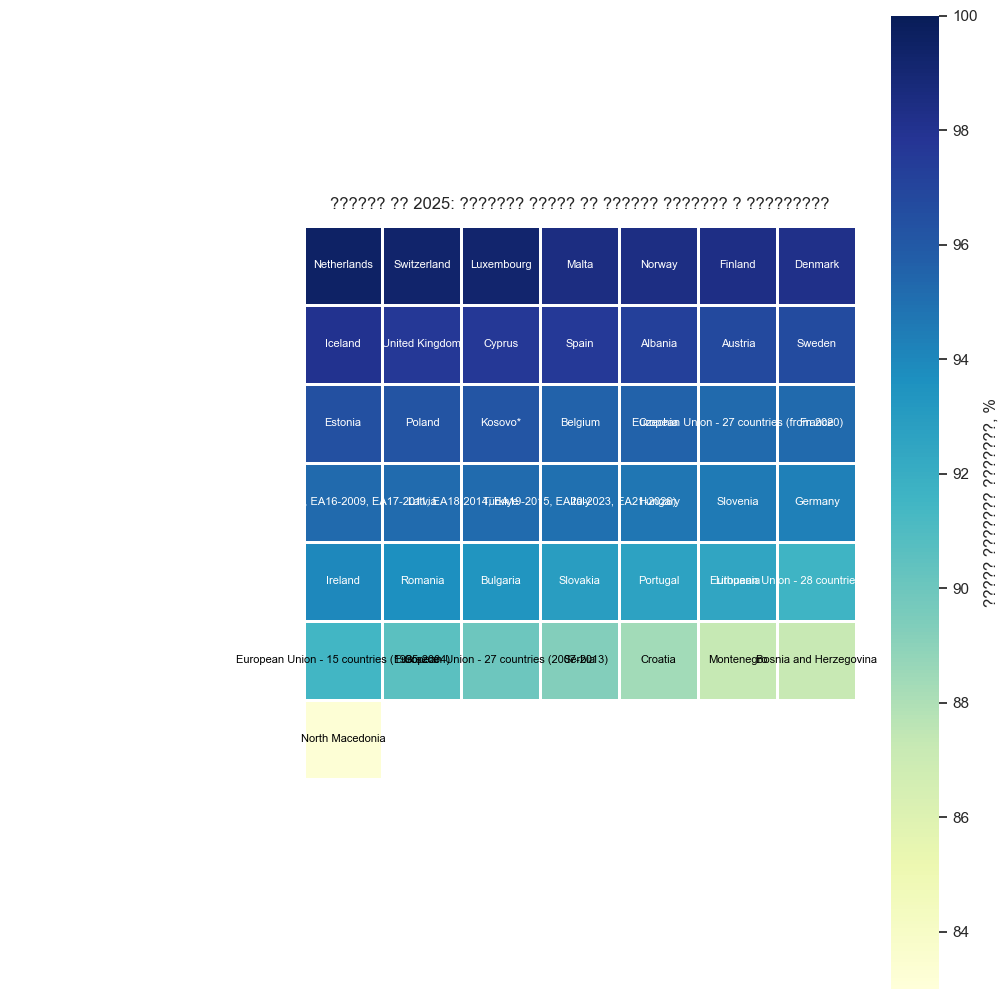

????? ?? ???????: 43
????? ? fallback (???? ???? ?? 1 ??? ?? ?? 2025): 11
????? ? ?????? ??????? 4 ?????: 42
???-5 ????? ?? ?????? ?????? ???????:


,country,total_pct,n_types,max_fallback_years
0,Netherlands,99.49,4,0
1,Switzerland,99.31,4,0
2,Luxembourg,99.24,4,0
3,Malta,98.53,4,0
4,Norway,98.43,4,0


???-5 ????? ?? ?????? ?????? ???????:


,country,total_pct,n_types,max_fallback_years
38,Serbia,89.30,4,4
39,Croatia,88.34,4,1
40,Montenegro,87.26,4,0
41,Bosnia and Herzegovina,87.25,4,0
42,North Macedonia,83.25,4,4


In [444]:
# ??????? ????? ?? ?????? ?????? ??????? ? ????????? (2025, ? fallback)
# Total: ?????????? ??????? ?? 4 ????? ????????????

target_year = 2025
base_types = [
    "Single person",
    "Single person with dependent children",
    "Two adults",
    "Two adults with dependent children",
]

# ????? ???? ????? (????? = 1.0)
type_weights = {
    "Single person": 0.25,
    "Single person with dependent children": 0.25,
    "Two adults": 0.25,
    "Two adults with dependent children": 0.25,
}

sub = df[df["household_type"].isin(base_types) & (df["year"] <= target_year)].copy()
if sub.empty:
    raise ValueError("??? ?????? ??? ??????? ? fallback ?? 2025 ????.")

# ??? ?????? ???? ?????????? ???????? ????????? ????????? ??? <= target_year
idx = sub.sort_values("year").groupby(["country", "household_type"])["year"].idxmax()
latest_by_type = sub.loc[idx, ["country", "household_type", "year", "internet_access_pct"]].copy()
latest_by_type = latest_by_type.rename(columns={"year": "year_used"})

# ??????? ?????????? total ?? ??????
latest_by_type["w"] = latest_by_type["household_type"].map(type_weights)

def weighted_total(g):
    w = g["w"].to_numpy(dtype=float)
    x = g["internet_access_pct"].to_numpy(dtype=float)
    return float(np.average(x, weights=w))

country_total = (
    latest_by_type.groupby("country", as_index=False)
    .apply(lambda g: pd.Series({
        "total_pct": weighted_total(g),
        "n_types": int(g["household_type"].nunique()),
        "max_fallback_years": int(target_year - g["year_used"].min()),
        "used_fallback": bool((g["year_used"] < target_year).any()),
    }))
    .sort_values("total_pct", ascending=False)
    .reset_index(drop=True)
)

# ????????? ?????????
n = len(country_total)
n_cols = int(np.ceil(np.sqrt(n)))
n_rows = int(np.ceil(n / n_cols))

value_grid = np.full((n_rows, n_cols), np.nan)
label_grid = np.full((n_rows, n_cols), "", dtype=object)

for i, row in country_total.iterrows():
    r, c = divmod(i, n_cols)
    value_grid[r, c] = row["total_pct"]
    label_grid[r, c] = row["country"]

mask = np.isnan(value_grid)

fig_w = max(10, n_cols * 1.45)
fig_h = max(7, n_rows * 1.45)
plt.figure(figsize=(fig_w, fig_h))

# ???????? ????? ?????? ??????????
vmin = float(np.floor(np.nanmin(value_grid)))
vmax = float(np.ceil(np.nanmax(value_grid)))

ax = sns.heatmap(
    value_grid,
    mask=mask,
    cmap="YlGnBu",
    vmin=vmin,
    vmax=vmax,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "????? ??????? ???????, %"},
    annot=label_grid,
    fmt="",
    annot_kws={"fontsize": 8, "ha": "center", "va": "center"},
)

# ???????? ??????
threshold = (vmin + vmax) / 2
for text in ax.texts:
    x, y = text.get_position()
    c = int(round(x - 0.5))
    r = int(round(y - 0.5))
    if 0 <= r < n_rows and 0 <= c < n_cols and not np.isnan(value_grid[r, c]):
        text.set_color("white" if value_grid[r, c] >= threshold else "black")

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
plt.title("?????? ?? 2025: ??????? ????? ?? ?????? ??????? ? ?????????", pad=12)
plt.tight_layout()
plt.show()

# ??????????? fallback ? ????????
n_countries = len(country_total)
n_fallback = int(country_total["used_fallback"].sum())
n_full_types = int((country_total["n_types"] == 4).sum())

print(f"????? ?? ???????: {n_countries}")
print(f"????? ? fallback (???? ???? ?? 1 ??? ?? ?? 2025): {n_fallback}")
print(f"????? ? ?????? ??????? 4 ?????: {n_full_types}")

print("???-5 ????? ?? ?????? ?????? ???????:")
display(country_total[["country", "total_pct", "n_types", "max_fallback_years"]].head(5).round(2))
print("???-5 ????? ?? ?????? ?????? ???????:")
display(country_total[["country", "total_pct", "n_types", "max_fallback_years"]].tail(5).round(2))


## III. Оценка параметров и доверительные интервалы (Тема 4)

### Оценка среднего за самый последний год
Эта ячейка оценивает средний уровень доступа к интернету за самый последний год и строит 95%-й доверительный интервал с использованием распределения Стьюдента (t).  

Она количественно отражает неопределённость вокруг среднего значения выборки.  
Интервальная оценка среднего значения генеральной совокупности интерпретируется как диапазон, в котором, вероятно, находится истинное среднее.  

Мы оцениваем среднее значение генеральной совокупности через среднее значение выборки и оцениваем вариативность через стандартное отклонение выборки, поэтому используется t-распределение.  
95%-й доверительный интервал означает, что если многократно повторять эксперимент, брать новые выборки и вычислять среднее, примерно 95% таких интервалов будут содержать истинное среднее генеральной совокупности μ.

In [445]:
# Mean estimation in the most recent year + 95% CI (t-Student)
x = df_latest["internet_access_pct"].to_numpy()
n = len(x)
mean_x = x.mean()
std_x = x.std(ddof=1)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
se_mean = std_x / math.sqrt(n)
ci_mean = (mean_x - t_crit * se_mean, mean_x + t_crit * se_mean)

print(f"Estimated mean ({latest_year}): {mean_x:.3f}%")
print(f"95% CI for the population mean: [{ci_mean[0]:.3f}, {ci_mean[1]:.3f}]")
print("Interpretation: with 95% confidence, the true mean lies within this interval.")


Estimated mean (2025): 94.645%
95% CI for the population mean: [93.537, 95.752]
Interpretation: with 95% confidence, the true mean lies within this interval.


### Насколько распространён высокий уровень доступа к интернету в наборе данных
Эта ячейка оценивает долю наблюдений с доступом к интернету на уровне 80% и выше и строит 95%-й доверительный интервал.  

Она подсчитывает, сколько случаев удовлетворяют порогу, и переводит это в долю.  
Показывает, насколько часто встречается высокий уровень доступа к интернету в наборе данных.  

SE (стандартная ошибка) измеряет, насколько оценённая доля может варьироваться от одной выборки к другой.

In [446]:
# Estimate of a proportion: p = P(access >= 80%) in the most recent year
threshold = 80
success = (df_latest["internet_access_pct"] >= threshold).sum()
p_hat = success / n
z_crit = stats.norm.ppf(0.975)
se_p = math.sqrt(p_hat * (1 - p_hat) / n)
ci_prop = (p_hat - z_crit * se_p, p_hat + z_crit * se_p)

print(f"Selected threshold: {threshold}%")
print(f"Estimated proportion p-hat: {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"95% CI for the proportion: [{ci_prop[0]:.4f}, {ci_prop[1]:.4f}]")
print("Interpretation: the interval estimates the share of observations with high internet access.")


Selected threshold: 80%
Estimated proportion p-hat: 0.9571 (95.71%)
95% CI for the proportion: [0.9236, 0.9907]
Interpretation: the interval estimates the share of observations with high internet access.


## IV. Проверка гипотез (Тема 5)

Мы проверяем, равно ли среднее значение процента доступа к интернету за самый последний год 75%.

- $H_0: \mu = 75$  
- $H_1: \mu \ne 75$

### t-тест для одной выборки
Эта ячейка выполняет t-тест для одной выборки за самый последний год — равняется ли среднее значение доступа к интернету 75%?  

Она вычисляет t-статистику и p-значение, затем формулирует статистическое решение (отклонить/не отклонять H0).  

Мы проверяем гипотезу $H_0: \mu = 75$ и альтернативную гипотезу $H_1: \mu \ne 75$, то есть отличается ли средний процент от 75%.  
t-статистика показывает, насколько среднее значение выборки отклоняется от предполагаемого значения.  

p-значение показывает вероятность получить такие значения, если H0 верна.  
Если `ttest.pvalue < 0.05`, мы проверяем H0 и решаем, принимать её или отклонять при уровне значимости 5%.

In [447]:
mu0 = 75
ttest = stats.ttest_1samp(df_latest["internet_access_pct"], popmean=mu0)

print(f"One-sample t-test, year {latest_year}")
print(f"t statistic = {ttest.statistic:.4f}")
print(f"p-value = {ttest.pvalue:.6g}")

if ttest.pvalue < 0.05:
    print("Conclusion (alpha=0.05): reject H0. The mean differs significantly from 75%.")
else:
    print("Conclusion (alpha=0.05): fail to reject H0.")


One-sample t-test, year 2025
t statistic = 35.0755
p-value = 6.39123e-71
Conclusion (alpha=0.05): reject H0. The mean differs significantly from 75%.


## V. Проверка зависимостей для категориальных переменных (Тема 6)

Мы оцениваем, существует ли связь между:  
- типом домохозяйства (`household_type`) и  
- категорией доступа (`high_access`: $\geq 90\%$ против $<80\%$).

### Тест хи-квадрат
Эта ячейка создаёт категориальную переменную высокого доступа (`>= 90%` против `< 90%`), формирует таблицу сопряжённости с типом домохозяйства и выполняет тест хи-квадрат на независимость.  

Она изучает, связаны ли тип домохозяйства и категория высокого доступа.  
Используются статистика хи-квадрат и p-значение для вывода о зависимости между двумя категориальными переменными.  

Статистика chi2 показывает, насколько сильно отличаются наблюдаемые значения от ожидаемых при независимости данных.  
p-значение показывает вероятность появления такой закономерности случайным образом.

In [448]:
df_latest = df_latest.copy()
df_latest["high_access"] = np.where(df_latest["internet_access_pct"] >= 90, "Yes", "No")

contingency = pd.crosstab(df_latest["household_type"], df_latest["high_access"])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print("Contingency table:")
display(contingency)

print(f"χ² = {chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p_chi2:.6g}")
print(f"Minimum expected frequency = {expected.min():.3f}")

if p_chi2 < 0.05:
    print("Conclusion: reject independence. There is an association between variables.")
else:
    print("Conclusion: there is not enough evidence for an association.")


Contingency table:


high_access,No,Yes
household_type,,
Single person,21,15
Single person with dependent children,1,31
Two adults,8,28
Two adults with dependent children,0,36


χ² = 45.3203
Degrees of freedom = 3
p-value = 7.91034e-10
Minimum expected frequency = 6.857
Conclusion: reject independence. There is an association between variables.


## VI. Анализ дисперсии - ANOVA (Тема 7)

Мы сравниваем средние значения `internet_access_pct` для 4 типов домохозяйств за самый последний год.

- $H_0$: все средние значения групп равны  
- $H_1$: хотя бы одно среднее значение отличается

### Требования для ANOVA
Эта ячейка проверяет предположения ANOVA перед сравнением средних значений групп.  
Проверяются нормальность распределения внутри каждой группы (тест Шапиро–Уилка) и гомогенность дисперсий между группами (тест Левена).  
Предоставляется диагностическая информация о том, насколько классические предположения ANOVA выполняются.  
Мы сможем ответить на вопрос, различаются ли средние проценты доступа к интернету для разных типов домохозяйств.

Два обязательных предположения:  
1. Внутри каждой группы данные должны быть приблизительно нормально распределены (колоколообразная кривая).  
2. Все группы должны иметь похожий разброс (дисперсию).

In [449]:
# Checking ANOVA assumptions
anova_groups = [g["internet_access_pct"].values for _, g in df_latest.groupby("household_type")] # creating the groups

# Normality by groups (Shapiro-Wilk)
shapiro_rows = []
for name, g in df_latest.groupby("household_type"): # tesing normality (do the values look like normal distribution)
    stat, pval = stats.shapiro(g["internet_access_pct"])
    shapiro_rows.append({"household_type": name, "n": len(g), "W": stat, "p_value": pval})
shapiro_df = pd.DataFrame(shapiro_rows).sort_values("household_type")

# Homogeneity of variances (Levene) equality of variance
lev_stat, lev_p = stats.levene(*anova_groups, center="median")

print("Shapiro-Wilk by groups:")
display(shapiro_df)
print(f"Levene: stat={lev_stat:.4f}, p-value={lev_p:.6g}")


Shapiro-Wilk by groups:


,household_type,n,W,p_value
0,Single person,36,0.922300,1.471388e-02
1,Single person with dependent children,32,0.746947,4.747872e-06
2,Two adults,36,0.901628,3.781623e-03
3,Two adults with dependent children,36,0.691556,2.089931e-07


Levene: stat=14.1684, p-value=4.3414e-08


### Интерпретация ANOVA: F-статистика
Эта ячейка выполняет однофакторный ANOVA для типов домохозяйств за самый последний год.  
Исследовательский вопрос: равны ли средние значения всех групп или хотя бы одно отличается?  
Результат: F-статистика, p-значение и статистический вывод, а также средние значения групп для интерпретации.

F = дисперсия между группами / дисперсия внутри групп.  
Если F близка к 1, это означает, что группы похожи.

In [450]:
# Classical ANOVA
f_stat, p_anova = stats.f_oneway(*anova_groups)

print(f"ANOVA: F = {f_stat:.4f}, p-value = {p_anova:.6g}")

if p_anova < 0.05:
    print("Conclusion: reject H0. There are significant differences between means.")
else:
    print("Conclusion: fail to reject H0.")

means_latest = (
    df_latest.groupby("household_type")["internet_access_pct"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("mean")
)
print("\nGroup means:")
display(means_latest)


ANOVA: F = 37.7381, p-value = 8.26353e-18
Conclusion: reject H0. There are significant differences between means.

Group means:


,mean
household_type,
Two adults with dependent children,99.289722
Single person with dependent children,98.164062
Two adults,93.424722
Single person,88.090833


### Пост-хок анализ
Поскольку ANOVA показывает, что хотя бы одно среднее значение отличается, эта ячейка определяет, какие именно пары различаются.  
Выполняются попарные t-тесты Уэлча с корректировкой Холма для множественных сравнений.  
В результате получаются скорректированные p-значения и индикаторы значимости для каждой пары типов домохозяйств.

Пост-хок сравнения показывают статистически значимые различия между типами домохозяйств. Однако различия среди домохозяйств с детьми очень малы по величине (около 1 процентного пункта), что указывает на ограниченное практическое значение.

In [451]:
# Post-hoc analysis (Welch pairwise comparisons + Holm correction)
grouped = {name: g["internet_access_pct"].values for name, g in df_latest.groupby("household_type")}
comparisons = []
for g1, g2 in itertools.combinations(grouped.keys(), 2):
    t_stat, p_val = stats.ttest_ind(grouped[g1], grouped[g2], equal_var=False)
    comparisons.append({"group_1": g1, "group_2": g2, "t_stat": t_stat, "p_raw": p_val})

posthoc = pd.DataFrame(comparisons)
reject, p_adj, _, _ = multipletests(posthoc["p_raw"], method="holm")
posthoc["p_adj_holm"] = p_adj
posthoc["significant_difference"] = reject
posthoc = posthoc.sort_values("p_adj_holm")

display(posthoc)


,group_1,group_2,t_stat,p_raw,p_adj_holm,significant_difference
2,Single person,Two adults with dependent children,-8.386956,5.695007e-10,3.417004e-09,True
0,Single person,Single person with dependent children,-7.184579,7.053938e-09,3.526969e-08,True
5,Two adults,Two adults with dependent children,-6.906304,3.755981e-08,1.502392e-07,True
3,Single person with dependent children,Two adults,4.984631,6.959945e-06,2.087984e-05,True
1,Single person,Two adults,-3.398587,1.218929e-03,2.437859e-03,True
4,Single person with dependent children,Two adults with dependent children,-2.379400,2.257643e-02,2.257643e-02,True


### Визуализация ANOVA
Эта ячейка визуализирует различия между группами ANOVA с помощью boxplot-графиков за самый последний год.  

Она помогает интерпретировать результаты статистического теста, показывая перекрытие и разделение распределений.  
Визуальная сводка различий между группами согласуется с результатами ANOVA и пост-хок анализа.

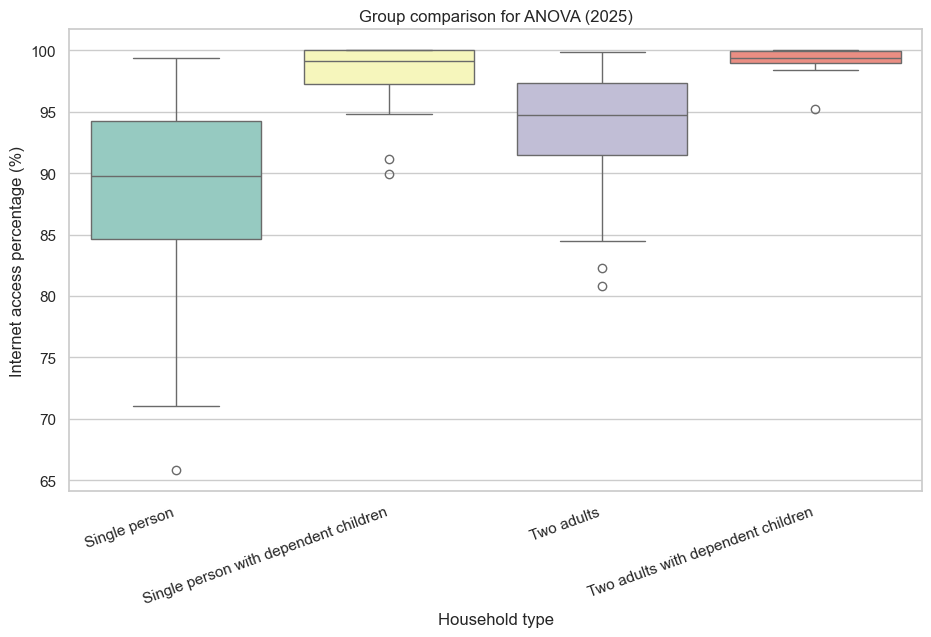

In [452]:
# Visualization for mean comparison (useful for ANOVA interpretation)
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_latest,
    x="household_type",
    y="internet_access_pct",
    hue="household_type",
    dodge=False,
    palette="Set3",
    legend=False,
)
plt.title(f"Group comparison for ANOVA ({latest_year})")
plt.xlabel("Household type")
plt.ylabel("Internet access percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.show()


## VII. ?????? ? ????????????

### ?????? ???????????
?????? ??????????, ??? ? ????? ???? ???????????? ? ???????? ? ????????? ? ?????? ???????, ?? ??????????? ?? ????? ????????????.  
??? ????? `2025` (?????? ?????? 2025 ????, ??? ??????????? ??????? ???) ?????????? ??????? ???? ??????? ??????????? ? `???+????` ? `????+????`, ? ?????????? ? ? `????`.  
t-????, ???? $\chi^2$ ? ANOVA ???????????? ?????????????? ?????????? ????????, ? ????-??? ?????? ??????????, ????? ?????? ?????? ???????????? ??? ???????? ???????? ??????? ?????.

### ??????????? ?????????????
??? ????????????? ????? ???????????? ??? ???????????? ???????? ??????????? ??? ???????????? ????????-??????? ? ???????? ?????:
- ??? digital-first ????????? ???????? ? ?????? ??????? ????????????? ??????????????? ?? ????????????? ? ??????, ??? ???? ??????? ? ????????? ???????????;
- ??? ????? ? ????? ?????? ??????? ??????? (?????? ????? `????`, ???????? `???`) ????? ???????????? ????????? ?????? ???????????? (?????? + ??????) ? ???????? ???????? ???????? ??????? ? ???????.

???????????? ????: ?????????? ???????? ???????????? ???????? ????????????? ??????-???????????? ? ??????? ???? ????????? ?????????? ? ????? ???????????? ?????.

### ???????????
- ????? ?????? ???????? ?????????????? ??????????, ? ?? ?????? ?? ?????? ????????? ????????????.  
- ???????? ???????? ? ????????? ????? ?????? ????? ???????? ? ??????.  
- ??????????? ANOVA ? ???????????? ? ???????????? ????????? ??????????? ?? ????????, ??????? ????????????? ??????? ????????????.

### ????????? ??????????
- ????????? ??????????? ?????? ?? ???????.  
- ?????????? ????????????? ??????? ? ?????? ????????? ????????? ? ????????? ???????.
